In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
#Combined CMIP6 Hist+Proj Mean, 17th/83rd quantile
cmip6_members = pd.read_csv("/home/emily_zuetell/projects/poreallas/analysis/pop_weighted_anomaly_cmip6_members_proj.csv")
#Convert year to datetime
cmip6_members['date'] = pd.to_datetime(cmip6_members['time'], format='%Y')

In [ ]:
#Monthly average ERA5
era5 = pd.read_csv("/home/emily_zuetell/projects/poreallas/analysis/pop_weighted_anomaly_era5.csv")
#Convert time to datetime
era5['date'] = pd.to_datetime(era5['time'])
era5 = era5[['date', 'era5_anomaly']]
#If needed: Annual Average of Forecast Months
#era5 = era5[era5['date'].dt.month.isin([8, 9, 10, 11, 12, 1])].groupby(era5['date'].dt.year).mean()

In [ ]:
#Monthly forecast Mean, 17th/83rd quantile
forecast = pd.read_csv("/home/emily_zuetell/projects/poreallas/analysis/pop_weighted_anomaly_forecast_members.csv")
#Select only 6 months
forecast = forecast[forecast['month'].isin([8, 9, 10, 11, 12, 1])]
#Convert time to datetime
forecast['date'] = pd.to_datetime(forecast['time'])

Text(0, 0.5, 'Population-weighted temperature anomaly (C)')

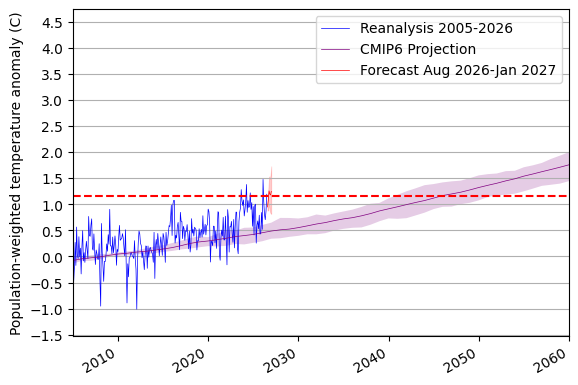

In [ ]:
fig, ax = plt.subplots()
cmip6_p17 = cmip6_members['lower']
cmip6_p83 = cmip6_members['upper']


era5.plot(x = 'date', y = 'era5_anomaly', linewidth = .5, color = 'blue', ax = ax, label = "Reanalysis 2005-2026", x_compat=True)
#CMIP6 mean and shaded likely range
cmip6_members.plot(x = 'date', y = 'mean', linewidth = .5, color = 'purple', ax = ax, label = "CMIP6 Projection")
ax.fill_between(cmip6_members['date'].to_numpy(), cmip6_p17.to_numpy(), cmip6_p83.to_numpy(), color='purple', alpha=0.2, linewidth=0)
#Forecast mean and shaded likely range
forecast.plot(x = 'date', y = 'mean', linewidth = .5, color = 'red', ax = ax, label = "Forecast Aug 2026-Jan 2027")
ax.fill_between(forecast['date'].to_numpy(), forecast['lower'].to_numpy(), forecast['upper'].to_numpy(), color='red', alpha=0.2, linewidth=.5)
#Forecast average
plt.axhline(forecast['mean'].mean(), color = 'red', linestyle = "--")

#Align X-Axis
ax.xaxis.set_major_locator(mdates.YearLocator(10, month=1, day=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2060-01-01'))
ax.set_xlabel("")

ax.grid(axis='y')
ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.set_ylabel("Population-weighted temperature anomaly (C)")

In [ ]:
#Combine data into CSV for production
combined = (
    era5[['date', 'era5_anomaly']]
    .rename(columns={'era5_anomaly': 'era5_anomaly'})
    .merge(
        cmip6_members[['date', 'mean', 'lower', 'upper']].rename(
            columns={'mean': 'cmip6_mean', 'lower': 'cmip6_lower', 'upper': 'cmip6_upper'}
        ),
        on='date', how='outer'
    )
    .merge(
        forecast[['date', 'mean', 'lower', 'upper']].rename(
            columns={'mean': 'forecast_mean', 'lower': 'forecast_lower', 'upper': 'forecast_upper'}
        ),
        on='date', how='outer'
    )
    .sort_values('date')
)

In [74]:
combined.to_csv('time_series_postcard_data.csv')

In [ ]:
#Check forecast year
print(forecast_6mo_mean['forecast_mean'])
print(cmip6_members['mean'][cmip6_members['time']==2045])

50    1.124292
Name: mean, dtype: float64